In [61]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)

import matplotlib.pyplot as plt
import seaborn as sns

import config
from data_utils import best_players_plots, table_simulation, expected_stats_vs_actuals, sort_data, colors_config

In [3]:
data = pd.read_parquet(config.TIDY_DATA_PATH)

In [4]:
data = sort_data(data)
data.head()

,position,team_name,match_id,web_name,second_name,first_name,status,player_code,touches_opposition_box,gw,team_code,id,selected_by_percent,ep_this,goals_conceded,threat,expected_assists,fouls_committed,now_cost,xgot,chances_created,penalties_scored,tackles_won,value_season,ict_index,clearances,accurate_passes_percent,blocks,successful_dribbles_percent,xa,creativity,tackles_won_percent,xgot_faced,value_form,selected_rank,influence,penalties_order,successful_dribbles,gk_accurate_long_balls,transfers_in_event,finish_min,accurate_crosses,interceptions,tackles,sweeper_actions,aerial_duels_won_percent,was_fouled,corners_and_indirect_freekicks_order,headed_clearances,bonus,total_points,offsides,duels_lost,form,event_points,accurate_crosses_percent,ground_duels_won,ground_duels_won_percent,start_min,gk_accurate_passes,team_strength,transfers_out,cost_change_event,saves,aerial_duels_won,accurate_passes,goals_prevented,dreamteam_count,bps,expected_goals_conceded,assists,ep_next,transfers_out_event,penalties_missed,duels_won,final_third_passes,dribbled_past,now_cost_rank,recoveries,minutes_played,touches,expected_goal_involvements,chance_of_playing_next_round,cost_change_start,direct_freekicks_order,goals,transfers_in,team_goals_conceded,xg,accurate_long_balls_percent,shots_on_target,big_chances_missed,high_claim,accurate_long_balls,total_shots,chance_of_playing_this_round,expected_goals,season_id,xg_per_90,xa_per_90,expected_goal_involvements_per_90,expected_goals_conceded_per_90,was_home,value_ratio
0,MID,Brighton,24-25-prem-everton-vs-brighton-&-hove-albion,Milner,Milner,James,a,15157,2,1,36,134,0.1,1.6,0,4,0.11,1,5.0,0.0,3,0,2,0.4,7.0,0,85,2,0,0.11,43.8,50,0.0,0.4,471,22.4,6,0,0,513,82,2,0,4,0,0,0,1,0,0,2,0,2,2.0,2,29,4,80,0,0,3,421,0,0,0,28,0.0,0,10,0.45,0,1.6,421,0,4,2,0,172,0,82,48,0.11,0,0,7,0,513,0,0.0,33,0,0,0,1,0,0,0.0,2425,0.0,0.120732,0.120732,0.493902,False,0.4
1,MID,Brighton,24-25-prem-brighton-&-hove-albion-vs-mancheste...,Milner,Milner,James,a,15157,2,2,36,134,0.1,2.0,0,12,0.15,1,5.0,0.0,1,0,0,0.8,10.7,2,73,0,100,0.04,66.2,0,0.0,0.4,448,28.6,6,1,0,1189,73,1,1,1,0,0,1,1,0,0,4,0,1,2.0,2,100,3,75,0,0,3,1548,0,0,0,22,0.0,0,22,1.77,0,1.0,635,0,3,6,0,177,2,73,42,0.31,0,0,7,0,2267,1,0.16,0,1,0,0,0,2,0,0.16,2425,0.19726,0.049315,0.382192,2.182192,True,0.4
2,MID,Brighton,24-25-prem-arsenal-vs-brighton-&-hove-albion,Milner,Milner,James,d,15157,0,3,36,134,0.1,0.7,0,12,0.15,1,5.0,0.0,0,0,0,1.0,10.7,0,100,0,0,0.0,66.3,0,0.0,0.3,461,28.6,6,0,0,472,17,0,1,0,0,0,0,1,0,0,5,0,1,1.7,1,0,0,0,0,0,3,4535,0,0,0,2,0.0,0,24,1.98,0,1.7,1998,0,0,0,0,185,0,17,4,0.31,75,0,7,0,4199,0,0.0,0,0,0,0,0,0,0,0.16,2425,0.0,0.0,1.641176,10.482353,False,0.2
3,MID,Brighton,24-25-prem-tottenham-hotspur-vs-brighton-&-hov...,Milner,Milner,James,a,15157,0,38,36,134,0.0,0.0,0,12,0.15,0,5.0,0.0,0,0,0,1.2,10.7,0,0,0,0,0.0,66.3,0,0.0,0.0,586,28.6,6,0,0,0,93,0,0,0,0,0,0,8,0,0,6,0,0,0.2,1,0,0,0,93,0,3,10991,0,0,0,0,0.0,0,27,1.98,0,0.0,0,0,0,1,0,192,0,1,1,0.31,100,0,7,0,5014,0,0.0,0,0,0,0,0,0,0,0.16,2425,0.0,0.0,27.9,178.2,False,0.2
4,MID,Brighton,25-26-prem-brighton-hove-albion-vs-fulham,Milner,Milner,James,a,15157,0,1,36,170,0.1,0.0,0,0,0.0,0,4.9,0.0,0,0,0,3.1,0.0,0,0,0,0,0.0,0.1,0,0.0,0.0,467,0.0,1,0,0,113,90,0,0,0,0,0,0,5,0,0,1,0,0,0.0,1,0,0,0,0,0,3,20304,0,0,0,1,0.0,0,3,0.24,0,-0.5,497,0,0,0,0,283,0,2,1,0.0,100,-1,7,0,14413,1,0.0,0,0,0,0,0,0,0,0.0,2526,0.0,0.0,0.0,10.8,True,0.204082


In [5]:
data.describe()

,player_code,touches_opposition_box,gw,team_code,id,selected_by_percent,ep_this,goals_conceded,threat,expected_assists,fouls_committed,now_cost,xgot,chances_created,penalties_scored,tackles_won,value_season,ict_index,clearances,accurate_passes_percent,blocks,successful_dribbles_percent,xa,creativity,tackles_won_percent,xgot_faced,value_form,selected_rank,influence,penalties_order,successful_dribbles,gk_accurate_long_balls,transfers_in_event,finish_min,accurate_crosses,interceptions,tackles,sweeper_actions,aerial_duels_won_percent,was_fouled,corners_and_indirect_freekicks_order,headed_clearances,bonus,total_points,offsides,duels_lost,form,event_points,accurate_crosses_percent,ground_duels_won,ground_duels_won_percent,start_min,gk_accurate_passes,team_strength,transfers_out,cost_change_event,saves,aerial_duels_won,accurate_passes,goals_prevented,dreamteam_count,bps,expected_goals_conceded,assists,ep_next,transfers_out_event,penalties_missed,duels_won,final_third_passes,dribbled_past,now_cost_rank,recoveries,minutes_played,touches,expected_goal_involvements,chance_of_playing_next_round,cost_change_start,direct_freekicks_order,goals,transfers_in,team_goals_conceded,xg,accurate_long_balls_percent,shots_on_target,big_chances_missed,high_claim,accurate_long_balls,total_shots,chance_of_playing_this_round,expected_goals,season_id,xg_per_90,xa_per_90,expected_goal_involvements_per_90,expected_goals_conceded_per_90,value_ratio
count,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.0,20337.000000,20337.0,20337.0,20337.0,20337.0,20337.0
mean,300540.385455,1.669666,17.35964,29.346069,351.03265,4.102414,2.512455,0.092492,86.112652,0.582009,0.705561,5.324133,0.091515,0.608595,0.006294,0.437626,7.077381,31.692565,1.601416,47.871859,0.2344,13.313714,0.058899,94.742007,19.099621,0.091114,0.469951,250.583616,136.320539,5.573241,0.460638,0.357575,22066.159365,79.295373,0.273492,0.520677,1.072085,0.038108,19.307371,0.682598,7.150268,0.828047,1.984462,24.688253,0.005999,3.195604,2.526041,2.785662,6.177656,2.26115,26.626887,12.096229,1.402026,3.195604,352765.437134,-0.007228,0.188769,0.935094,23.700398,0.001818,0.330776,104.804789,9.259104,0.063825,2.45844,18048.827802,0.001377,3.196243,3.433151,0.47475,271.850125,3.080985,63.751143,40.809854,1.48099,53.225648,-0.785809,6.409107,0.089492,384720.42671,1.154497,0.092358,19.990067,0.28249,0.093377,0.053744,1.32935,0.787628,53.283424,0.899077,2468.554605,0.190587,0.108782,4.124931,26.17044,0.52248
std,163628.235147,2.254452,10.135853,28.111388,207.635376,8.347528,2.064307,0.464676,165.1745,1.073811,0.958443,1.260168,0.253987,0.989332,0.083913,0.885263,5.803097,46.378294,2.252382,41.248534,0.570364,30.428904,0.112784,159.71983,35.893856,0.421632,0.33774,187.364306,190.816298,1.253617,0.899633,1.62509,66682.143699,28.356842,0.688747,0.865388,1.395493,0.257983,34.287602,0.970356,2.037618,1.445742,4.321164,34.315363,0.090149,2.81347,1.903773,2.982976,19.855535,2.223564,33.009721,27.524191,5.710706,0.761739,873450.439671,0.319656,0.859251,1.414358,19.81864,0.194781,0.875453,140.825747,12.085241,0.258334,2.050695,56103.563225,0.038384,2.747968,3.630596,0.811784,193.135488,2.740422,32.716416,26.260616,2.800094,49.457197,2.146794,1.604972,0.315568,976148.720094,1.143099,0.203902,33.034971,0.608348,0.3329,0.329229,2.029653,1.184075,49.306822,1.998937,50.021

In [6]:
data.shape

(20337, 104)

In [7]:
data[~data['match_id'].str.contains('prem', na=False)]

,position,team_name,match_id,web_name,second_name,first_name,status,player_code,touches_opposition_box,gw,team_code,id,selected_by_percent,ep_this,goals_conceded,threat,expected_assists,fouls_committed,now_cost,xgot,chances_created,penalties_scored,tackles_won,value_season,ict_index,clearances,accurate_passes_percent,blocks,successful_dribbles_percent,xa,creativity,tackles_won_percent,xgot_faced,value_form,selected_rank,influence,penalties_order,successful_dribbles,gk_accurate_long_balls,transfers_in_event,finish_min,accurate_crosses,interceptions,tackles,sweeper_actions,aerial_duels_won_percent,was_fouled,corners_and_indirect_freekicks_order,headed_clearances,bonus,total_points,offsides,duels_lost,form,event_points,accurate_crosses_percent,ground_duels_won,ground_duels_won_percent,start_min,gk_accurate_passes,team_strength,transfers_out,cost_change_event,saves,aerial_duels_won,accurate_passes,goals_prevented,dreamteam_count,bps,expected_goals_conceded,assists,ep_next,transfers_out_event,penalties_missed,duels_won,final_third_passes,dribbled_past,now_cost_rank,recoveries,minutes_played,touches,expected_goal_involvements,chance_of_playing_next_round,cost_change_start,direct_freekicks_order,goals,transfers_in,team_goals_conceded,xg,accurate_long_balls_percent,shots_on_target,big_chances_missed,high_claim,accurate_long_balls,total_shots,chance_of_playing_this_round,expected_goals,season_id,xg_per_90,xa_per_90,expected_goal_involvements_per_90,expected_goals_conceded_per_90,was_home,value_ratio


In [8]:
data = data[data['match_id'].str.contains('prem', na=False, case=False)]


In [9]:
match_id_team_name_map = {'arsenal':'Arsenal','aston-villa':'Aston Villa','afc-bournemouth':'Bournemouth','brentford':'Brentford','brighton-&-hove-albion':'Brighton','burnley':'Burnley','chelsea':'Chelsea','crystal-palace':'Crystal Palace','everton':'Everton','fulham':'Fulham','ipswich-town':'Ipswich','leeds-united':'Leeds','leicester-city':'Leicester','liverpool':'Liverpool','manchester-city':'Man City','manchester-united':'Man Utd','newcastle-united':'Newcastle','nottingham-forest':"Nott'm Forest",'southampton':'Southampton','tottenham-hotspur':'Spurs','sunderland':'Sunderland','west-ham-united':'West Ham','wolverhampton-wanderers':'Wolves'}
data['was_home'] = pd.to_numeric(data['team_name'] == data['match_id'].str.split('-vs-').str[0].str.split('prem-').str[1].map(match_id_team_name_map))

In [10]:
raw_home = data['match_id'].str.split('-vs-').str[0].str.split('prem-').str[1]
raw_home[~raw_home.isin(match_id_team_name_map.keys())].unique()[0]

'brighton-hove-albion'

In [11]:
match_id_team_name_map[raw_home[~raw_home.isin(match_id_team_name_map.keys())].unique()[0]] = "Brighton"

In [12]:
data['was_home'] = pd.to_numeric(data['team_name'] == data['match_id'].str.split('-vs-').str[0].str.split('prem-').str[1].map(match_id_team_name_map))

In [13]:
data.was_home.isna().sum()

np.int64(0)

Text(0, 0.5, 'Liczba graczy')

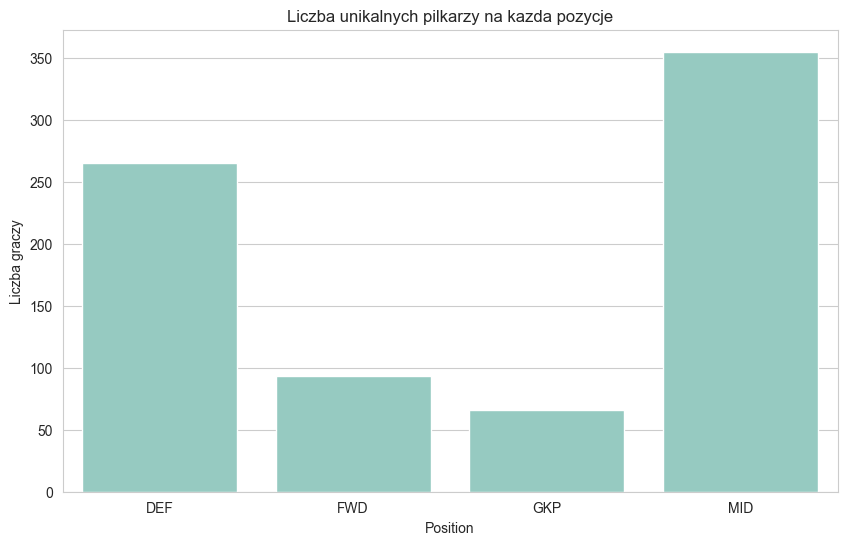

In [14]:
plt.figure(figsize=(10,6))
sns.barplot(data.groupby("position")["web_name"].nunique())
plt.title("Liczba unikalnych pilkarzy na kazda pozycje")
plt.xlabel("Position")
plt.ylabel("Liczba graczy")

In [15]:
[c for c in data.columns if "points" in c]

['total_points', 'event_points']

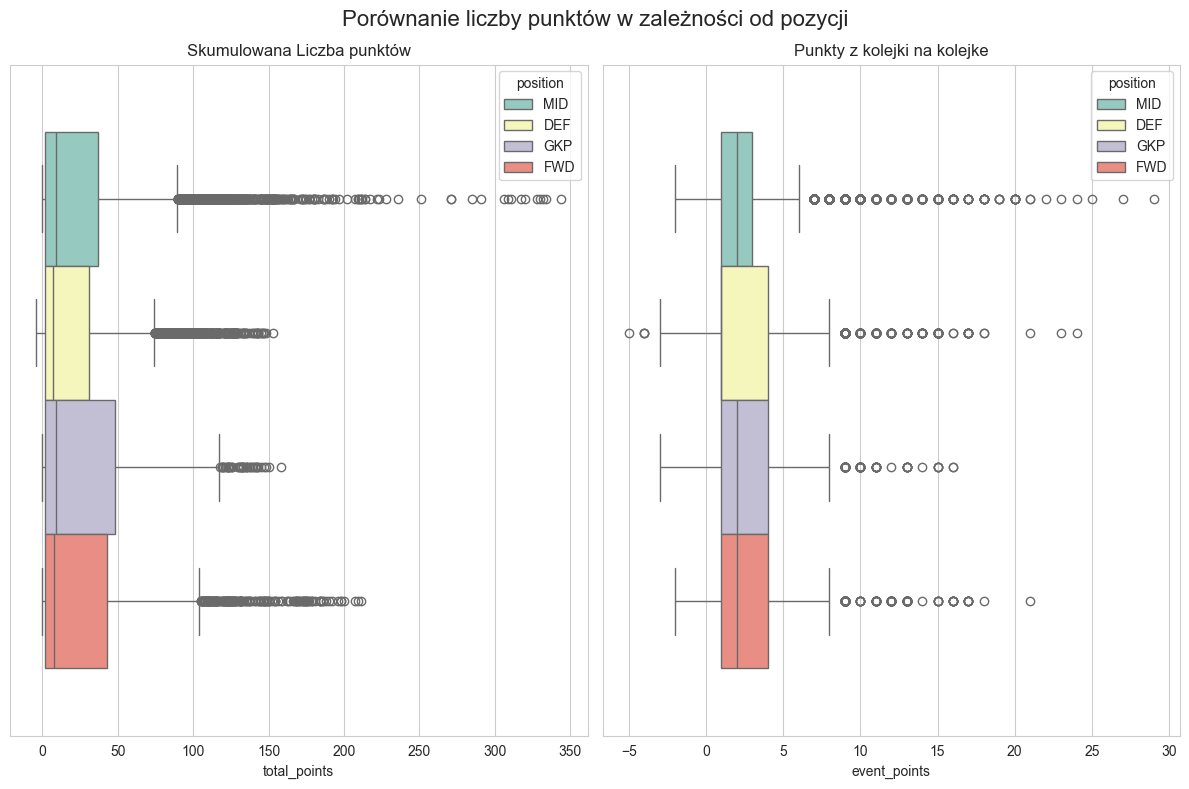

In [16]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 8))

sns.boxplot(data=data, x="total_points", hue="position", ax=ax[0])
sns.boxplot(data=data, x="event_points", hue="position", ax=ax[1])

ax[0].set_title("Skumulowana Liczba punktów")
ax[1].set_title("Punkty z kolejki na kolejke")
fig.suptitle("Porównanie liczby punktów w zależności od pozycji", fontsize=16)

plt.tight_layout()


C:\Users\russa\AppData\Local\Temp\ipykernel_3360\1319640155.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  ax = sns.histplot(data.event_points,


Text(0.5, 1.0, 'Rozkład Event Points')

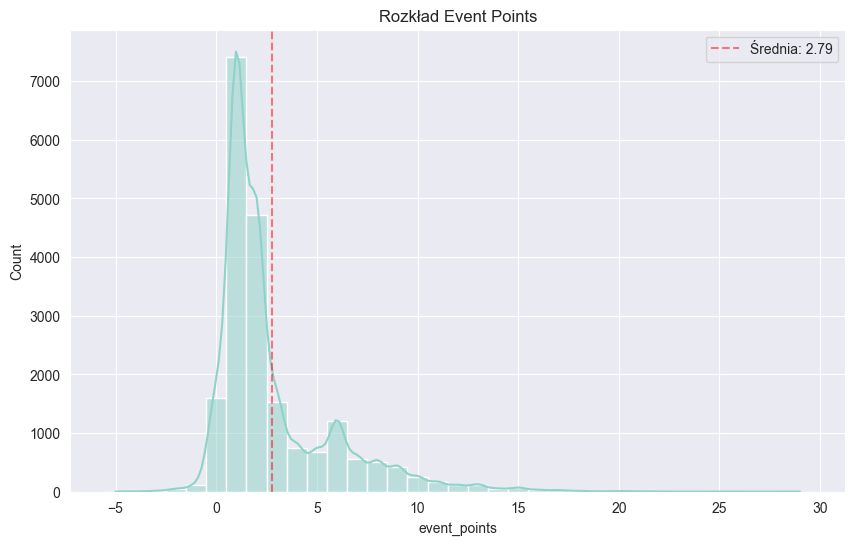

In [54]:
plt.figure(figsize=(10,6))

ax = sns.histplot(data.event_points,
             kde=True,
            palette="magma",
             discrete=True,
             bins=30)
ax.axvline(data.event_points.mean(), linestyle="--", color="r", alpha=0.5, label=f"Średnia: {data.event_points.mean():.2f}")
plt.legend(loc="upper right")
plt.title("Rozkład Event Points")

<Axes: >

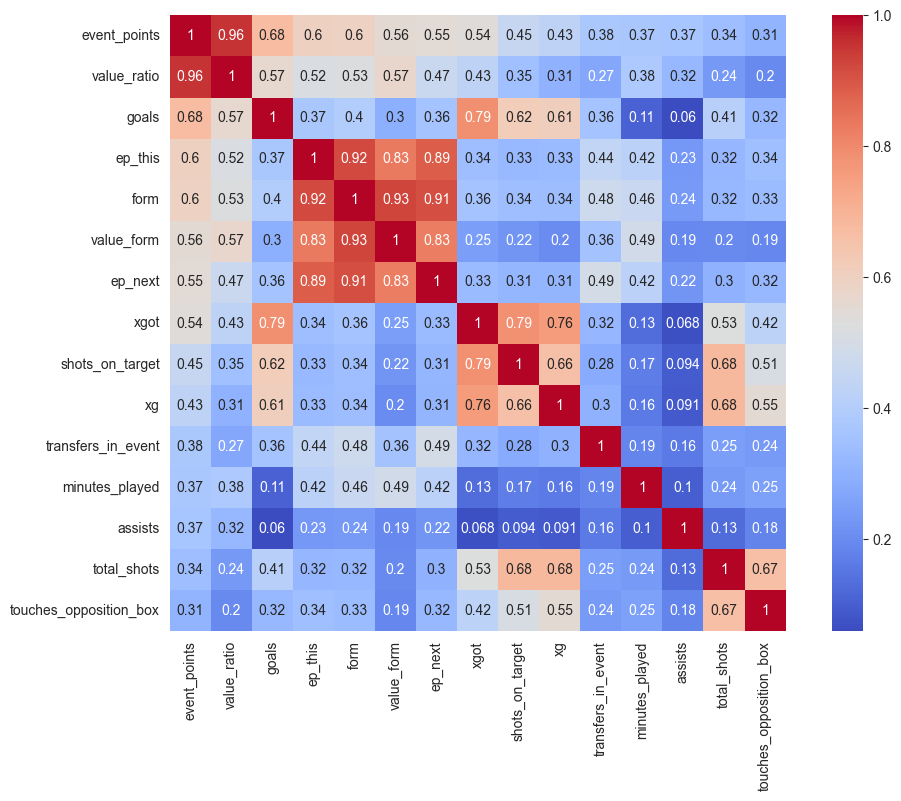

In [18]:
corr = data.select_dtypes(exclude=["object", "string"]).corr().apply(np.abs)
cols = corr["event_points"].sort_values(ascending=False).head(15).index

plt.figure(figsize=(12, 8))
sns.heatmap(corr.loc[cols, cols], annot=True, cmap="coolwarm", square=True)

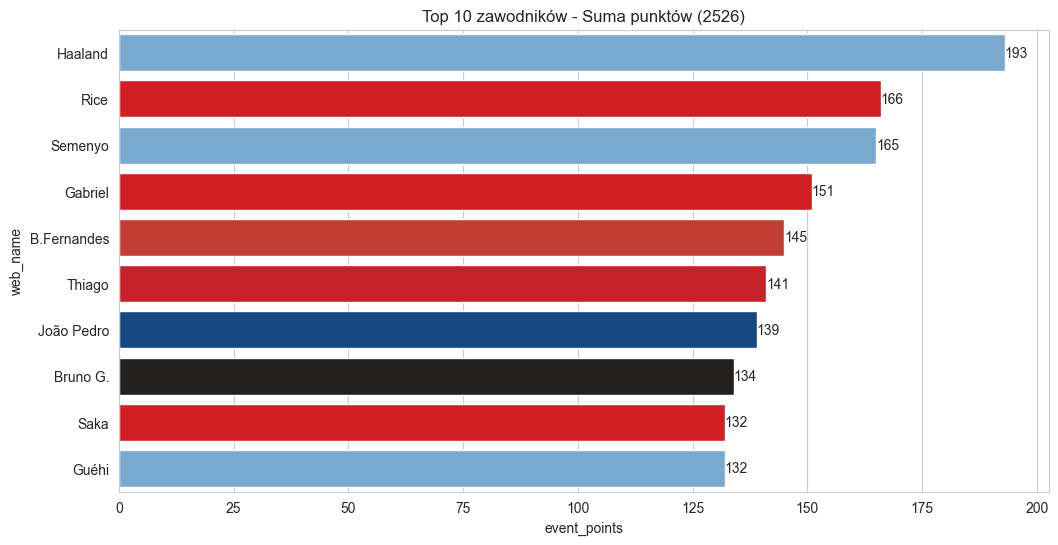

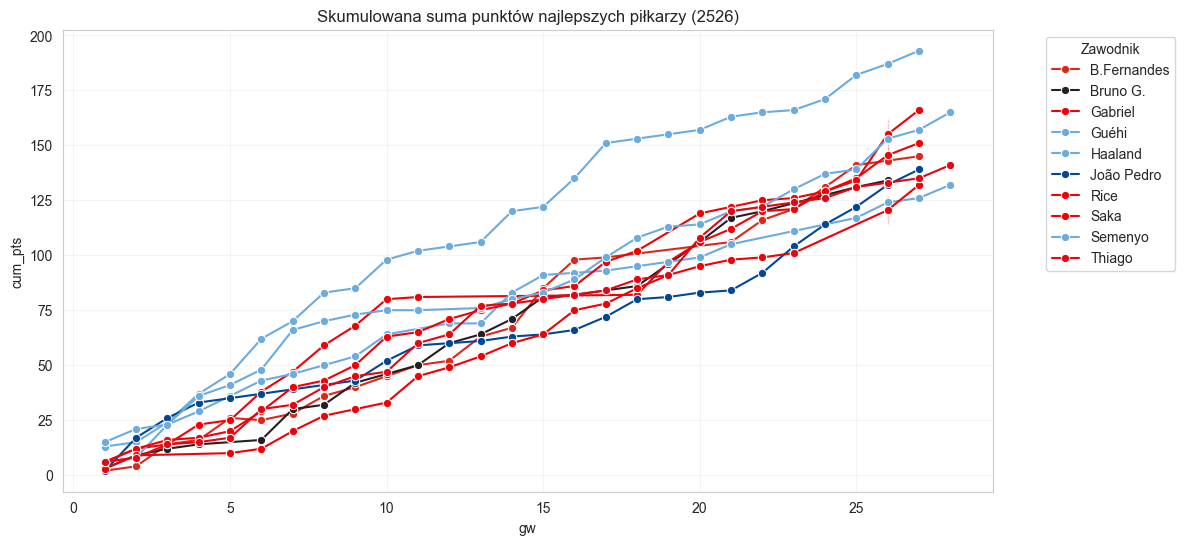

In [19]:
best_players_plots(df=data,
                   num_players=10,
                   season=2526)

In [20]:
data["value_ratio"] = (data.event_points / data.now_cost).fillna(0)


In [21]:
data[["web_name", "value_ratio", "position", "gw", "season_id"]].sort_values(by="value_ratio", ascending=False).head()

,web_name,value_ratio,position,gw,season_id
16944,Van de Ven,4.893617,DEF,9,2526
6566,Barnes,4.576271,MID,32,2425
18301,Schade,4.509804,MID,13,2425
12236,Lewis-Potter,4.375,DEF,17,2526
13933,J.Timber,4.363636,DEF,2,2526


In [22]:
x_cols = [c for c in data.columns if "expected" in c]

In [23]:
x_cols

['expected_assists',
 'expected_goals_conceded',
 'expected_goal_involvements',
 'expected_goals',
 'expected_goal_involvements_per_90',
 'expected_goals_conceded_per_90']

In [60]:
data.columns.to_list()[:10]

['position',
 'team_name',
 'match_id',
 'web_name',
 'second_name',
 'first_name',
 'status',
 'player_code',
 'touches_opposition_box',
 'gw']

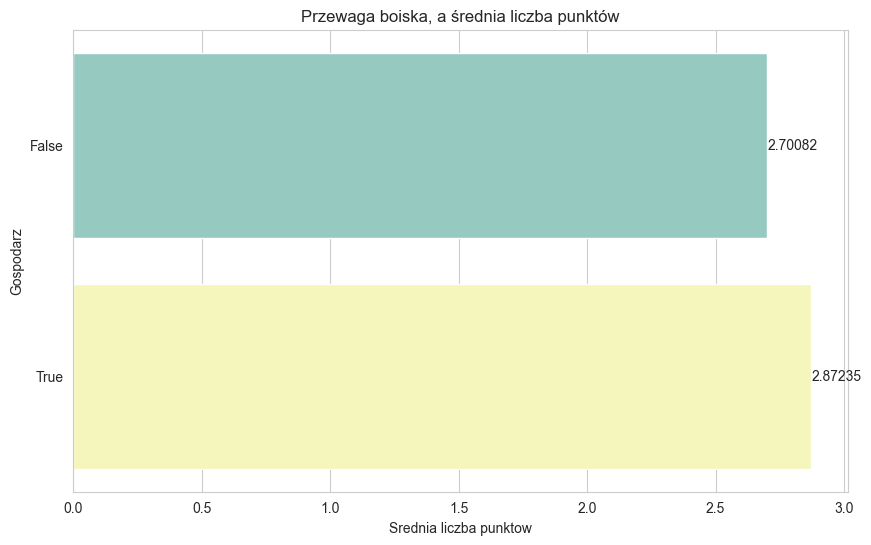

In [25]:
plt.figure(figsize=(10,6))
ax = sns.barplot(
    data=data,
    y="was_home",
    x="event_points",
    hue="was_home",
    estimator="mean",
    legend=False,
    errorbar=None,
    orient="h")

plt.xlabel("Srednia liczba punktow")
plt.ylabel("Gospodarz")

for container in ax.containers:
    ax.bar_label(container)
plt.title("Przewaga boiska, a średnia liczba punktów");

In [26]:
teams_avenue_form = data.groupby(["season_id", "team_name", "was_home"])["event_points"].mean().reset_index()
teams_avenue_form = teams_avenue_form.pivot(index=["season_id", "team_name"], columns="was_home", values="event_points")

# Zmień na 1 i 0 jeśli Twoje was_home to zera i jedynki
teams_avenue_form["home_advantage"] = teams_avenue_form[True] - teams_avenue_form[False]

# Zostawiamy nazwy drużyn i sezonu, zamieniając je z powrotem na zwykłe kolumny!
teams_avenue_form.reset_index(inplace=True)

teams_avenue_form.sort_values(by="home_advantage", ascending=False, inplace=True)
teams_avenue_form.columns.name = None

In [27]:
teams_avenue_form.head()

,season_id,team_name,False,True,home_advantage
37,2526,Sunderland,2.310185,3.374408,1.064222
33,2526,Man Utd,2.728507,3.522167,0.793661
24,2526,Brighton,2.314894,3.0625,0.747606
1,2425,Aston Villa,2.576052,3.314879,0.738827
30,2526,Leeds,2.3,3.031111,0.731111


In [28]:
teams_avenue_form.tail()

,season_id,team_name,False,True,home_advantage
38,2526,West Ham,2.570175,2.331776,-0.2384
12,2425,Man City,3.426966,3.138298,-0.288668
18,2425,West Ham,2.541935,2.205298,-0.336637
28,2526,Everton,3.2,2.817757,-0.382243
36,2526,Spurs,3.28125,2.40553,-0.87572


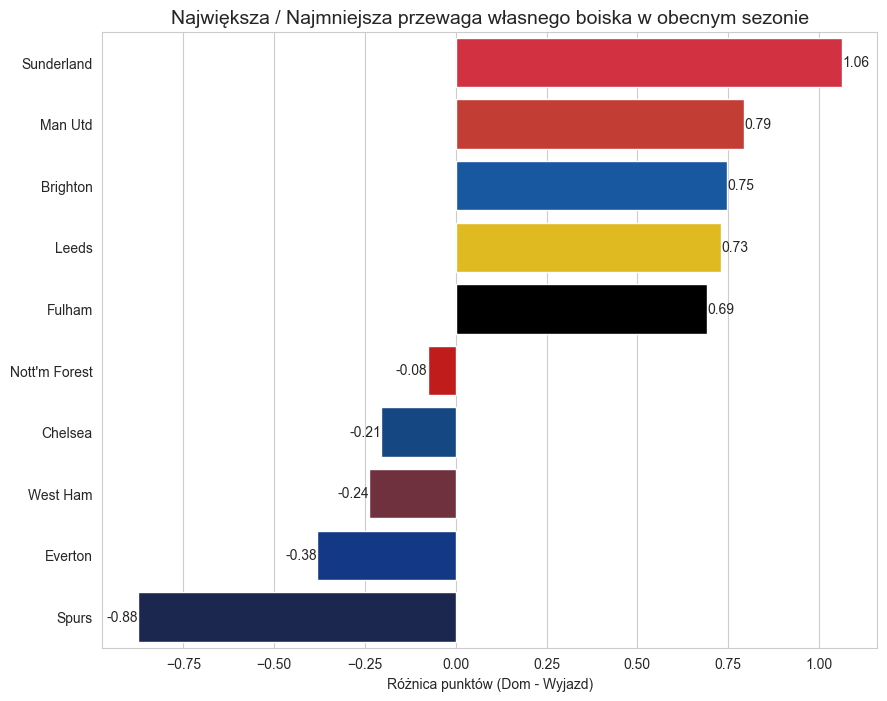

In [29]:
plt.figure(figsize=(10, 8))
ax =sns.barplot(data=pd.concat([teams_avenue_form[teams_avenue_form.season_id==2526].head(), teams_avenue_form[teams_avenue_form.season_id==2526].tail()], axis=0),
            x="home_advantage",
            hue="team_name",
            y="team_name",
            palette=colors_config.team_colors,
            errorbar=None)
plt.title("Największa / Najmniejsza przewaga własnego boiska w obecnym sezonie", fontsize=14)
plt.xlabel("Różnica punktów (Dom - Wyjazd)")
plt.ylabel("")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")


In [30]:
team_names = [t for t in data[data.season_id==2526].team_name.unique()]
team_names

['Brighton',
 'Everton',
 'Newcastle',
 'Burnley',
 'Bournemouth',
 'Brentford',
 'Crystal Palace',
 'Leeds',
 "Nott'm Forest",
 'Man Utd',
 'Aston Villa',
 'West Ham',
 'Fulham',
 'Sunderland',
 'Wolves',
 'Man City',
 'Liverpool',
 'Chelsea',
 'Arsenal',
 'Spurs']

In [31]:
data[data.season_id==2526].gw.unique()

<IntegerArray>
[ 1,  3,  4,  5,  7,  8,  9, 16, 17, 19, 20, 21, 23, 24, 26, 27,  2,  6, 10,
 11, 12, 13, 14, 15, 18, 22, 25, 28]
Length: 28, dtype: Int64

In [32]:
[c for c in data.columns if "sele" in c]

['selected_by_percent', 'selected_rank']

In [33]:
data.position.unique()

<ArrowStringArray>
['MID', 'DEF', 'GKP', 'FWD']
Length: 4, dtype: string

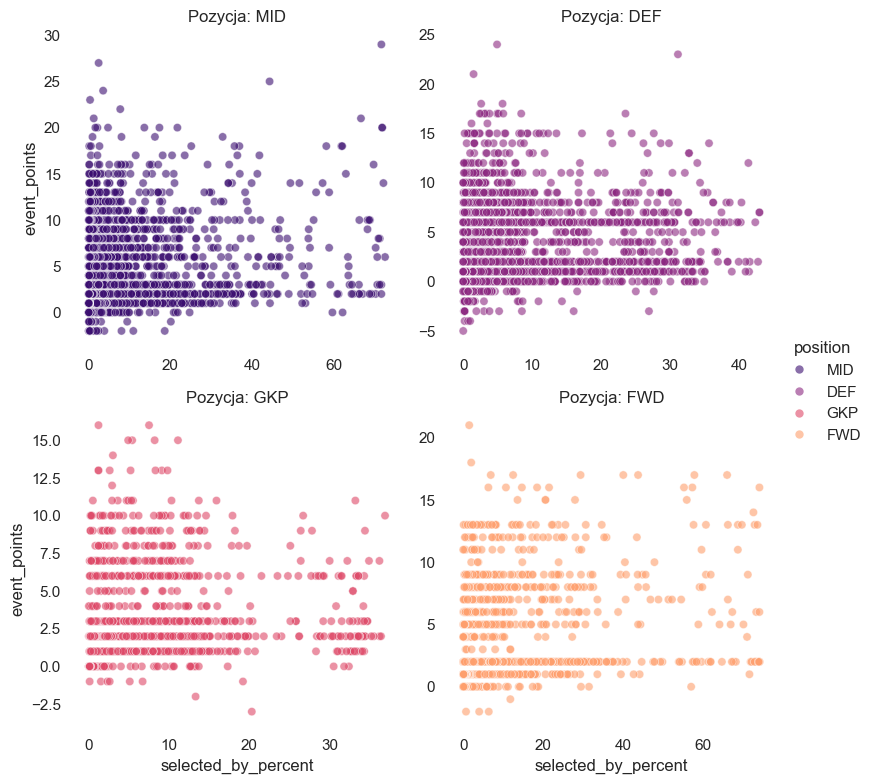

In [62]:
g = sns.relplot(
    data=data,
    x="selected_by_percent",
    y="event_points",
    col="position",
    hue="position",
    col_wrap=2,
    palette="magma",
    kind="scatter",
    alpha=0.6,
    height=4,
    facet_kws={'sharex': False, 'sharey': False}

)

g.set_titles("Pozycja: {col_name}")

plt.show()

In [ ]:
"""data.to_parquet(config.TIDY_DATA_PATH)"""